In [3]:
import numpy as np
import matplotlib.pyplot as plt

Nbody_shi

Direct N-body solver: for each step, the algorithm evaluates the force acted on any particles by all the other particles. RUNNING TIME SCALES AS $N^2$ 

$$G = 1$$
$$\textbf{f}_i=\sum_{j\neq i} \frac{m_im_j}{|\textbf{r}_{ij}|^3}\textbf{r}_{ij}$$

4^th order Hermite algorithm: error scales as dt^4

$$\textbf{x}_{i+1}=\textbf{x}_i+\textbf{v}_idt+\frac{1}{2}\textbf{a}_idt^2+\frac{1}{3!}\textbf{J}_idt^3+\frac{1}{4!}\textbf{S}_idt^4$$

$$\textbf{v}_{i+1}=\textbf{v}_i+\textbf{a}_idt+\frac{1}{2}\textbf{J}_idt^2+\frac{1}{3!}\textbf{S}_idt^3+\frac{1}{4!}\textbf{C}_idt^4$$

$$\textbf{a}_{i+1}=\textbf{a}_i+\textbf{J}_idt+\frac{1}{2}\textbf{S}_idt^2+\frac{1}{3!}\textbf{C}_idt^3+O(dt^4)$$

$$\textbf{J}_{i+1}=\textbf{J}_i+\textbf{S}_idt+\frac{1}{2}\textbf{C}_idt^2+O(dt^3)$$


where $\textbf{J}$ is the jerk, $\textbf{S}$ the snap (jounce), $\textbf{C}$ the crakle. The jerk can be evaluated knowing the position and the velocity vector only: 

$$\textbf{a}_i=\sum_{j\neq i} \frac{m_j}{|\textbf{r}_{ij}|^3}\textbf{r}_{ij}$$
$$\textbf{J}_i=\frac{d}{dt}\textbf{a}_i=\sum_{j\neq i}m_j\left( \frac{\textbf{v}_{ij}}{|\textbf{r}_{ij}|^3}-3\frac{\textbf{r}_{ij}}{|\textbf{r}_{ij}|^4}\frac{d}{dt}|\textbf{r}_{ij}|\right)$$

but $|\textbf{r}_{ij}|=\sqrt{\textbf{r}_{ij}\cdot \textbf{r}_{ij}}$ thus: 

$$\textbf{J}_i=\sum_{j\neq i}\frac{m_j}{|\textbf{r}_{ij}|^3}\left(\textbf{v}_{ij}-3\frac{\textbf{r}_{ij}}{|\textbf{r}_{ij}|}\frac{2(\textbf{v}_{ij}\cdot \textbf{r}_{ij})}{2|\textbf{r}_{ij}|}\right)=\sum_{j\neq i}\frac{m_j}{|\textbf{r}_{ij}|^3}\left(\textbf{v}_{ij}-3\frac{\textbf{r}_{ij}(\textbf{v}_{ij}\cdot \textbf{r}_{ij})}{|\textbf{r}_{ij}|^2}\right)$$


ALGORITHM

Step 1: PREDICTOR evaluates $\textbf{a}_i$ and $\textbf{J}_i$ from initial position and velocity and computes $\textbf{x}_{i+1}$ and $\textbf{v}_{i+1}$ to the order 2. 

Step 2: EVALUATOR computes $\textbf{C}_i$ and $\textbf{S}_i$ inverting the last two equations

Step 3: CORRECTOR computes higher order $\textbf{x}_i+1$ and $\textbf{v}_i+1$ by plugging snap and crakle in the Taylor expansion. 


How to decide $dt$? For each particle the algorithm computes $|\frac{\textbf{x}_{ij}}{\textbf{v}_{ij}}|$ and $|\frac{\textbf{x}_{ij}}{\textbf{a}_{ij}}|^{\frac{1}{2}}$, which are times. Then it takes the minimum between this two and multyplies it by an accuracy parameter $d\ll 1$. A good choice is $d=0.03$.




Internal units: $G_{IU} = 1$. $\frac{GM}{rv^2}$ is adimensional. 

$$\frac{M_{IU}}{r_{IU}v_{IU}^2}=\frac{G_{cgs}M_{cgs}}{r_{cgs}v_{cgs}^2}$$

We are free to chose any unit for $M$ and $r$, but $v$ will have to be consistent:

$$v_{IU}=\sqrt{\frac{r_{cgs}}{G_{cgs}M_{cgs}}}v_{cgs}$$

We need to tranform time units in internal units as well. $\frac{rt}{v}$ is adimensional.


    
    
    

In [4]:
G_cgs = 6.67259 * 10**-8 #G in cgs
M_sun = 1.9891 * 10**33 #solar mass in g
R_sun = 6.9598 * 10**10 #solar radius in cm 
M_earth = 5.976 * 10**27 #earth mass in g
R_earth = 6.378 * 10**8 #earth radius in cm
ly = 9.463 * 10**17 #light year in cm
parsec = 3.086 * 10**18 #parsec in cm
AU = 1.496 * 10**13 #astronomical unit in cm

If we chose as the internal units $M_\odot$, $1AU$ the velocity will be:

In [5]:
def v_IU(M_cgs, r_cgs, v_cgs):
    return np.sqrt(r_cgs/(G_cgs*M_cgs))*v_cgs

#def t_IU()


print(v_IU(M_sun,AU,30*10**5))


1.0071902724389827


./nbody_sh1 -d 0.03 -e 1.0 -o 0.01 -t 50 < initial_condition.in | awk '{print $2 " " $3}' > figure8.plot

d : accuracy parameter

e : how often the program writes energy in the terminal

o : how often the program writes the parameters in the terminal

t : integration total time

In [40]:
initial_conditions = np.loadtxt(r"/home/robertoinfurna/dynamics_of_stellar_systems/nbody_sh1/initial_conditions.in")
print(initial_conditions)

ValueError: the number of columns changed from 1 to 7 at row 3; use `usecols` to select a subset and avoid this error

In [31]:
output = np.loadtxt(r"/home/robertoinfurna/dynamics_of_stellar_systems/nbody_sh1/figure8.plot")
#orbits = np.genfromtxt(r"/home/robertoinfurna/Desktop/nbody_sh1/output.out", delimiter = ' ', usecols = range(1,3), invalid_raise = False)
#print(output)

In [32]:
orbit_1 = output[np.arange(0, len(output), 2, dtype="int16")].flatten()
orbit_2 = output[np.arange(1, len(output) + 1, 2, dtype="int16")].flatten()

relative_separation = orbit_1-orbit_2
#cdm_position = 

print(orbit_1)
print(orbit_2)
print(relative_separation)

[1.01323802e+00 2.68312379e-02 1.02640167e+00 ... 3.56815697e+01
 1.49056707e+01 3.57457871e+01]
[8.91951784e-05 7.88929464e-07 3.61212673e-04 ... 3.19870485e+01
 1.80532116e+01 3.21392004e+01]
[ 1.01314882  0.02683045  1.02604046 ...  3.69452121 -3.14754086
  3.60658669]


In [33]:
x_1 = orbit_1[np.arange(0, len(orbit_1), 2, dtype="int16")]
y_1 = orbit_1[np.arange(1, len(orbit_1) + 1, 2, dtype="int16")]
x_2 = orbit_2[np.arange(0, len(orbit_2), 2, dtype="int16")]
y_2 = orbit_2[np.arange(1, len(orbit_2) + 1, 2, dtype="int16")]
#x_3 = orbit_3[np.arange(0, len(orbit_3), 2, dtype="int16")]
#y_3 = orbit_3[np.arange(1, len(orbit_3) + 1, 2, dtype="int16")]

r_x = relative_separation[np.arange(0, len(orbit_1), 2, dtype="int16")]
r_y = relative_separation[np.arange(1, len(orbit_1) + 1, 2, dtype="int16")]

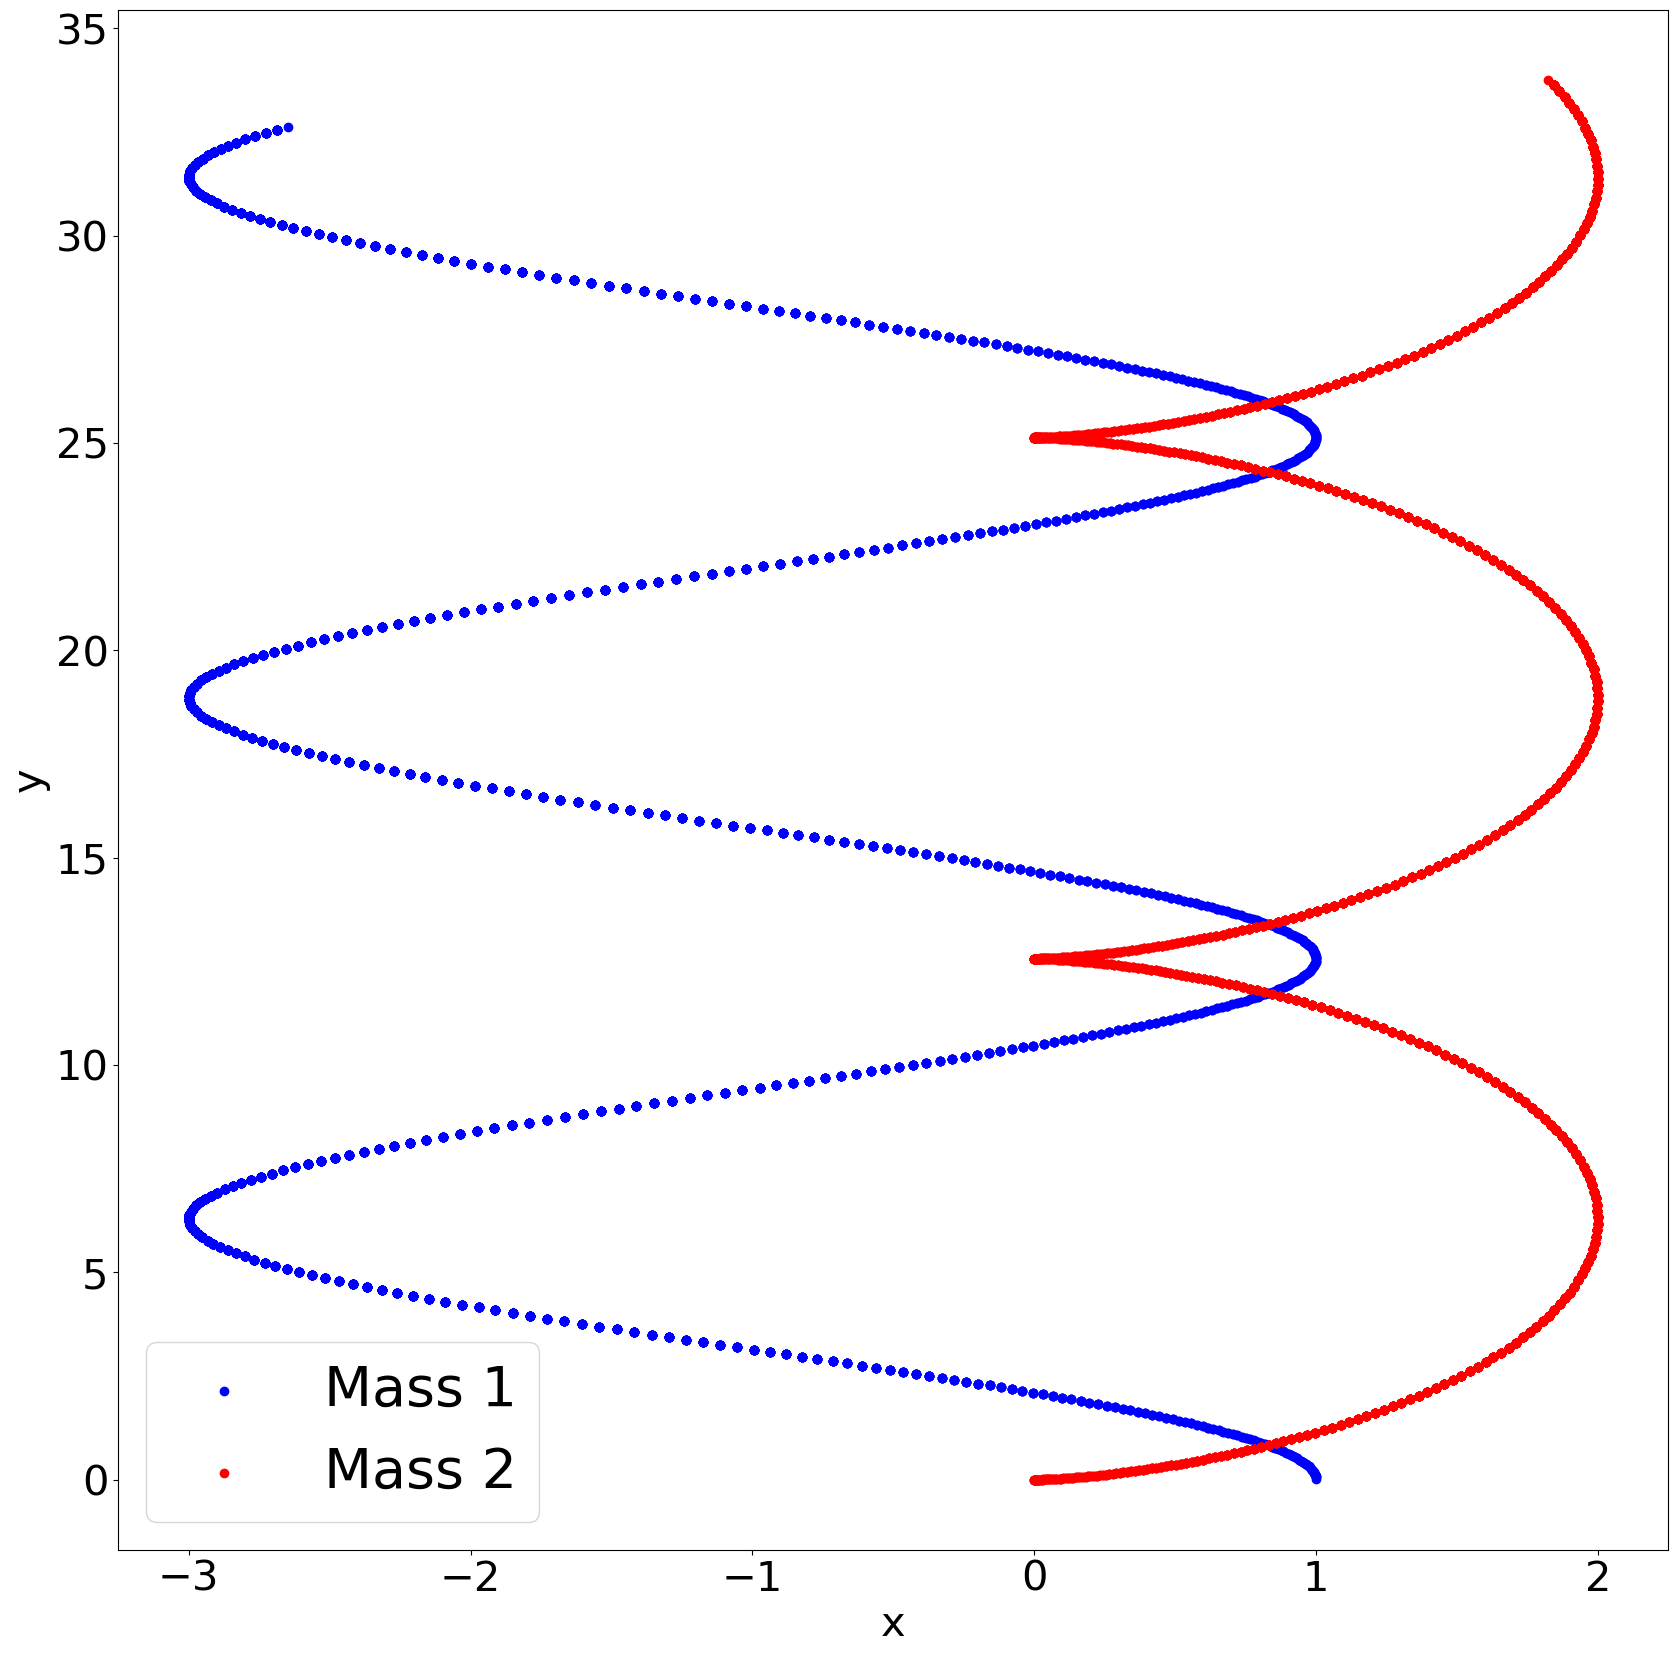

In [27]:
plt.figure(figsize=(20, 20))
plt.scatter(x_1, y_1, c="blue", label="Mass 1")
plt.scatter(x_2, y_2, c="red", label="Mass 2")
plt.xticks(size=30)
plt.yticks(size=30)
plt.xlabel("x", size=30)
plt.ylabel("y", size=30)
plt.legend(prop={"size": 40})

Let's compute $\dot{\hat{r}}$ and $\dot{\hat{\theta}}$ in cartesian coordinates:

$$\frac{d}{dt}\hat{r}=\frac{d}{dt}\cos{\theta}\hat{x}+\frac{d}{dt}\sin{\theta}\hat{y}=(-\sin{\theta}\hat{x}+\cos{\theta}\hat{y})$$

Text(0, 0.5, 'y')

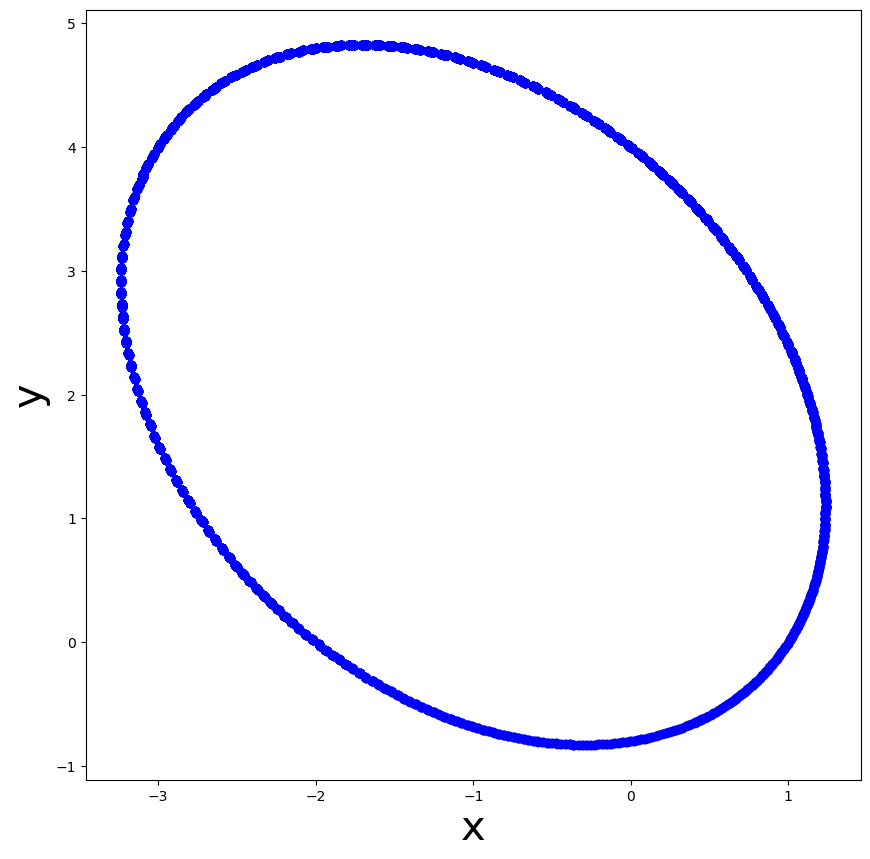

In [35]:
plt.figure(figsize=(10, 10))
plt.scatter(r_x, r_y, c="blue", label="relative separation")
#plt.scatter(x_2, y_2, c="red", label="Mass 2")
#plt.xticks(size=30)
#plt.yticks(size=30)
plt.xlabel("x", size=30)
plt.ylabel("y", size=30)
#plt.legend(prop={"size": 40})